    FOD1P  Cluster
0    1100        0
1    1101        0
2    1102        0
3    1103        0
4    1104        0
..    ...      ...
169  5504        0
170  5505        0
171  5506        0
172  5507        0
173  5599        0

[174 rows x 2 columns]


/var/folders/88/w4w1n8l12kd_z42_6mrnndmw0000gn/T/ipykernel_4873/2786804194.py:11: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  col = df.select_dtypes(include="object").columns[0]


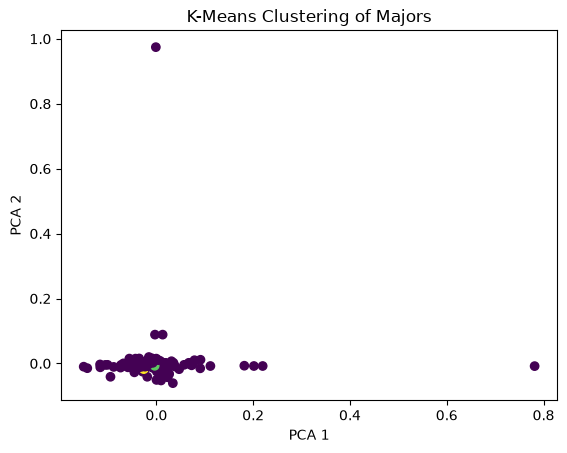

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Load dataset
df = pd.read_csv("majors-list.csv")

# Use the first text column
col = df.select_dtypes(include="object").columns[0]
text = df[col].fillna("").str.lower()

# NLP: TF-IDF
vectorizer = TfidfVectorizer(stop_words="english")
X = vectorizer.fit_transform(text)

# K-Means
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df["Cluster"] = kmeans.fit_predict(X)

# Show results
print(df[[col, "Cluster"]])

# PCA visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X.toarray())

plt.scatter(X_pca[:,0], X_pca[:,1], c=df["Cluster"], cmap="viridis")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("K-Means Clustering of Majors")
plt.show()

# Save results
df.to_csv("majors_clustered.csv", index=False)